## 7. EDOs de 2ª ordem com SymPy

### 7.1 Verificando soluções de EDOs de 2ª ordem com SymPy

**Exemplo 7.1: (Pêndulo)** Considere um pêndulo de comprimento $l$, com massa $m$ em sua extremidade, como ilustrado na figura abaixo.

<img
src="https://raw.githubusercontent.com/tiagoburiol/MatComp_III/refs/heads/main/Notebook%2004%20-%20EDOs%20de%201%C2%AA%20ordem%2C%20solu%C3%A7%C3%B5es%20anal%C3%ADticas%20com%20SymPy/imagens/pendulo.png" width="100"/>

O ângulo que o pêndulo faz com o eixo vertical ao longo do tempo, $\theta (t)$ na presença de gravidade vertical $g$ pode ser descrito pela equação do pêndulo, que é a EDO

$$
ml\frac{d^2\theta}{dt^2} = -mg \, sen \theta.
$$

Esta equação pode ser deduzida somando as forças nas direções $x$
e $y$ e, em seguida, mudando para coordenadas polares.

Essa é uma equação não linear de difícil solução mas pode ser simplificada assumindo que os ângulos são muito pequenos (ou seja, $sen \theta \approx \theta)$, então a equação do pêndulo se reduz a

$$
l\frac{d^2\theta}{dt^2} = -g\theta.
$$

e uma solução $\theta(t) = \cos\left(\sqrt{\frac{g}{l}}t\right)$ pode ser obtida. 

Para um ângulo inicial $\theta_0$, partindo do repouso no instante $t=0$, obtém-se a solução particular

$$\theta(t) = \theta_0\cos\left(\sqrt{\frac{g}{l}}t\right)$$

Podemos verificar calculando as derivadas de 1ª e 2ª ordens e substituindo na equação

**Exemplo 7.2:** Vamos verificar se $\theta(t) = \cos\left(\sqrt{\frac{g}{l}}t\right)$ é solução da equação

$$
l\frac{d^2\theta(t)}{dt^2} = -g\theta(t)
$$

utilizando SymPy

In [1]:
import sympy as sp

In [2]:
# definido os símbolos
t,g,l = sp.symbols('t,g,l', positive=True) 

In [3]:
# entrando com a função theta
theta = sp.cos(sp.sqrt(g/l)*t)

In [4]:
# lado esquerdo da equação (derivada segunda)
l*theta.diff(t, t)

-g*cos(sqrt(g)*t/sqrt(l))

In [5]:
# lado direito da equação
-g*theta

-g*cos(sqrt(g)*t/sqrt(l))

Podemos ver que que a função $\theta(t)$ satisfaz a equação, pois derivando duas vezes e substituindo, o lado direito e o lado esquerdo da equação são iguais. 

Outra forma de verificar é fazendo:

In [6]:
sp.Eq(l*theta.diff(t,t), -g*theta)

True

**Atividade 7.1** Verifique, utilizando SymPy, se a função $\theta(t) = \theta_0\cos\left(\sqrt{g/l}\,t\right) + \omega_0\sqrt{l/g}\,sen\left(\sqrt{g/l}\,t\right)$ satisfaz a equação do pêndulo linearizado $l\,\theta''=-g\theta$ e as condições iniciais $\theta(0)=\theta_0$ e $\theta'(0)=\omega_0$.

In [7]:
w0, theta0 = sp.symbols('w_0, theta_0', positive=True)

In [8]:
theta = theta0*sp.cos(sp.sqrt(g/l)*t)+w0*sp.sqrt(l/g)*sp.sin(sp.sqrt(g/l)*t)
theta

theta_0*cos(sqrt(g)*t/sqrt(l)) + sqrt(l)*w_0*sin(sqrt(g)*t/sqrt(l))/sqrt(g)

In [9]:
l*theta.diff(t,t)

-l*(sqrt(g)*w_0*sin(sqrt(g)*t/sqrt(l))/sqrt(l) + g*theta_0*cos(sqrt(g)*t/sqrt(l))/l)

In [10]:
-g*theta

-g*(theta_0*cos(sqrt(g)*t/sqrt(l)) + sqrt(l)*w_0*sin(sqrt(g)*t/sqrt(l))/sqrt(g))

In [11]:
theta.subs(t,0)

theta_0

In [12]:
theta.diff(t).subs(t,0).simplify()

w_0

### 7.2 Equações homogêneas com coeficientes constantes

As equações diferenciais homogêneas com coeficientes constantes e de 2ª ordem são aquelas que podem ser escritas na forma

$$ay''+by'+cy=0$$

com $a$, $b$ e $c$ constantes. A solução depende da natureza das raízes da equação característica $ar^2+br+c=0$.

#### 7.2.1 Raízes reais e distintas

Se a equação característica possuir **duas raízes reais e distintas** $r_1$ e $r_2$, em que $r_1 \neq r_2$, então  $y_1(t)=e^{r_1t}$ e $y_2(t)=e^{r_2t}$ são duas soluções da equação diferencial. Além disso, a combinação linear dessas duas soluções, ou seja, a função

$$ y = c_1e^{r_1t} + c_2e^{r_2t}$$

também é uma solução (confira!).

Se estivermos interessados em um elemento particular da família de soluções que satisfaz as condições iniciais

$$y(t_0)=y_0 \,\,\,\, \text{e}\,\,\,\, y'(t_0)=y'_0$$

então, substituindo na equação, podemos obter

$$c_1=\frac{y'_0-y_0r_2}{r_1-r_2}e^{-r_1t_0}\,\,\,\, \text{e}\,\,\,\,c_2=\frac{y_0r_1-y'_0}{r_1-r_2}e^{-r_2t_0}$$

**Exemplo 7.3:** Encontre a solução do problema de valor inicial

$$y''+5y'+6y=0  \, \text{,}\,\, y(0)=2 \,\, \text{e}\,\, y'(0)=3$$

_Solução:_

As raízes de $r^2+5r+6=0$ são $r_1=-2$ e $r_2=-3$. Então a solução geral da equação é

$$ y = c_1e^{-2t}+c_2e^{-3t}$$

Aplicando a primeira condição inicial $y(0)=2$ obtemos $c_1+c_2=2$.

Aplicando a segunda condição inicial $y'(0)=3$ obtemos $-2c_1-3c_2=3$.

Resolvendo o sistema linear formado por essas duas equações obtém-se $c_1=9$ e $c_2=-7$, então a solução particular é

$$y=9e^{-2t}-7e^{-3t}$$

Vejamos agora como usar as bibliotecas computacionais para obter essa solução.

In [13]:
r, c1, c2 = sp.symbols('r, c1, c2')

In [14]:
#resolvendo a equação característica 
sp.solve(r**2+5*r+6)

[-3, -2]

In [15]:
#escrevendo a solução geral
t = sp.symbols('t')
y = sp.Function('y')(t)
y = c1*sp.exp(-2*t)+c2*sp.exp(-3*t)
y

c1*exp(-2*t) + c2*exp(-3*t)

In [16]:
# verificando a solução
sp.simplify(y.diff(t,t)+ 5*y.diff(t)+6*y)

0

In [17]:
eq1 = sp.Eq(y.subs(t,0),2)
eq1

Eq(c1 + c2, 2)

In [18]:
eq2 = sp.Eq(y.diff(t).subs(t,0),3)
eq2

Eq(-2*c1 - 3*c2, 3)

In [19]:
C = sp.solve([eq1,eq2])
C

{c1: 9, c2: -7}

In [20]:
s_part = C[c1]*sp.exp(-2*t)+C[c2]*sp.exp(-3*t)
s_part

9*exp(-2*t) - 7*exp(-3*t)

O mesmo resultado poderia ser obtido fazendo simplesmente

In [21]:
y = sp.Function('y')(t)
eq = y.diff(t,t)+5*y.diff(t)+6*y
sp.dsolve(eq, y)

Eq(y(t), (C1 + C2*exp(-t))*exp(-2*t))

Para adicionar condições iniciais, podemos complementar o comando adicionando `ics={y(0): 2, y.diff(t).subs(t, 0): 3}` dentro do `dsolve`

In [22]:
sol = sp.dsolve(eq, y, ics={y.subs(t, 0):2, y.diff(t).subs(t, 0): 3})
sol

Eq(y(t), (9 - 7*exp(-t))*exp(-2*t))

Plotando a solução particular

In [23]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(4,3)

In [24]:
# sol.rhs é o lado direito da equação sol
f = sp.lambdify(t,sol.rhs)

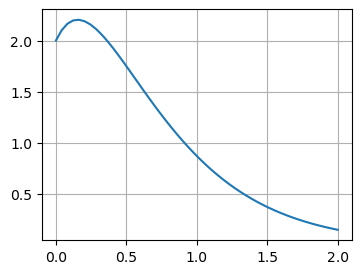

In [25]:
t = np.linspace(0,2)
plt.plot(t, f(t))
plt.grid()
plt.show()

**Atividade 7.2** Resolva o problema de valor inicial $y''+7y'+10y=0$, $y(0)=1$ e $y'(0)=-1$, primeiro à mão e depois conferindo com `sp.dsolve`. Plote a solução particular obtida para $t\in[0,2]$.

**Curiosidade:** O que acontece se eu plotar várias curvas para várias soluções?

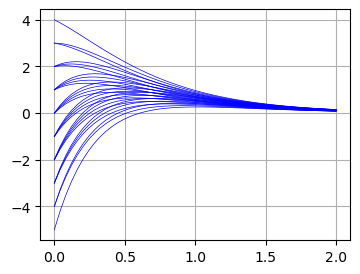

In [26]:
f = lambda t,c1,c2: (c1-c2*np.exp(-t))*np.exp(-2*t)
for c1 in np.arange(6,10):
    for c2 in np.arange(5,12):
        plt.plot(t, f(t,c1,c2),'b-',lw=0.5)
plt.grid()
plt.show()

#### 7.2.2 Raízes complexas conjugadas

Se a equação característica $ar^2+br+c=0$ possuir **raízes complexas conjugadas** $r_1 = \lambda + i\mu$ e $r_2 = \lambda - i\mu$, então a solução geral da equação diferencial é a função

$$ y = c_1 e^{\lambda t} cos(\mu t)+c_2 e^{\lambda t} sen(\mu t)$$

**Exemplo 7.4:** Encontre a solução do problema de valor inicial $16y"-8y'+145y=0$, $y(0)=-2$ e $y'(0)=1$.

In [27]:
t = sp.symbols('t')
y = sp.Function('y')(t)
eq = 16*y.diff(t,t)-8*y.diff(t)+145*y
sol_g = sp.dsolve(eq, y)
sol_g

Eq(y(t), (C1*sin(3*t) + C2*cos(3*t))*exp(t/4))

In [28]:
sol_p = sp.dsolve(eq, y, ics={y.subs(t, 0):-2, y.diff(t).subs(t, 0): 1})
sol_p

Eq(y(t), (sin(3*t)/2 - 2*cos(3*t))*exp(t/4))

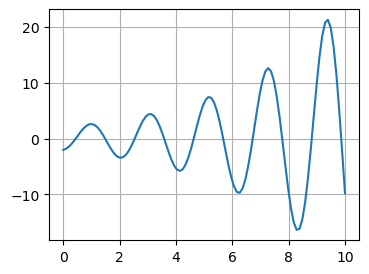

In [29]:
f = sp.lambdify(t,sol_p.rhs)
t = np.linspace(0,10,100)
plt.plot(t, f(t))
plt.grid()
plt.show()

In [30]:
display(sol_g.rhs)

(C1*sin(3*t) + C2*cos(3*t))*exp(t/4)

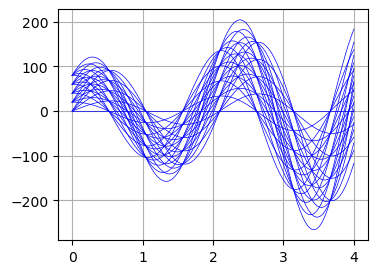

In [31]:
sols = lambda t,c1,c2: (c1*np.sin(3*t) + c2*np.cos(3*t))*np.exp(t/4)
t = np.linspace(0,4,100)

for c1 in range(0,100,20):
    for c2 in range(0,100,20):
        plt.plot(t, sols(t, c1,c2), 'b-', lw=0.5)
plt.grid()
plt.show()

**Exemplo 7.5:** Encontre a solução do problema de valor inicial $y''+9y=0$.

In [32]:
t = sp.symbols('t')
y = sp.Function('y')(t)
eq = y.diff(t,t)+9*y
sol_g = sp.dsolve(eq, y)
sol_g

Eq(y(t), C1*sin(3*t) + C2*cos(3*t))

In [33]:
print(sol_g.rhs)

C1*sin(3*t) + C2*cos(3*t)


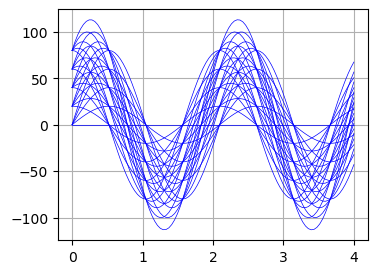

In [34]:
sols = lambda t,c1,c2: c1*np.sin(3*t) + c2*np.cos(3*t)
t = np.linspace(0,4,100)

for c1 in range(0,100,20):
    for c2 in range(0,100,20):
        plt.plot(t, sols(t, c1,c2), 'b-', lw=0.5)
plt.grid()
plt.show()

**Atividade 7.3** Encontre a solução do problema de valor inicial $y''+4y=0$, $y(0)=0$ e $y'(0)=2$, à mão e com `sp.dsolve`, e plote a solução no intervalo $[0,4]$.

#### 7.2.3 Raízes reais e iguais

Por fim, se a equação característica $ar^2+br+c=0$ possuir **raízes iguais** $r_1 = r_2$, então a solução geral é dada por

$$ y = c_1e^{r_1t}+c_2 t e^{r_2t}$$

**Exemplo 7.6:**
Encontre a solução do problema de valor inicial $y''-y'+0.25y=0$, $y(0)=2$ e $y'(0)=1/3$.

In [35]:
t = sp.symbols('t')
y = sp.Function('y')(t)
eq = y.diff(t,t)-y.diff(t)+0.25*y
sp.dsolve(eq, y)


Eq(y(t), C1*exp(0.499999999999937*t) + C2*exp(0.500000000000057*t))

Ops! Aqui parece que algo não deu certo, o que será??? 

In [36]:
#resolvendo a equação característica 
sp.solve(r**2-r+0.25)

[0.500000000000000]

Raízes iguais!!! A solução geral é $y(t) = C_1 e^{0.5t} + C_2te^{0.5t}$

**Nota:** o resultado do `sp.dsolve` no Exemplo 7.6 (duas exponenciais quase iguais, com expoentes `0.499999999999937` e `0.500000000000057`) não é um erro do SymPy — é um efeito de **ponto flutuante**. O coeficiente da equação foi escrito como `0.25`, um `float` do Python, e o SymPy resolveu a equação característica numericamente, encontrando duas raízes que deveriam ser iguais a $0,5$ mas diferem por um erro de arredondamento. Quando o mesmo coeficiente é escrito como uma fração exata com `sp.Rational`, o SymPy resolve a equação de forma simbólica e reconhece corretamente a raiz dupla:

In [37]:
eq_exato = y.diff(t,t) - y.diff(t) + sp.Rational(1,4)*y
sp.dsolve(eq_exato, y)

Eq(y(t), (C1 + C2*t)*exp(t/2))

Agora o SymPy reconhece a raiz dupla $r=0,5$ e devolve a forma correta $y(t) = (C_1+C_2t)e^{0,5t}$, coerente com a solução obtida manualmente. **Lição:** ao trabalhar com SymPy, prefira `sp.Rational` (ou símbolos exatos) a números decimais quando a exatidão simbólica importa.

**Atividade 7.4** Resolva $y''-6y'+9y=0$ com `sp.dsolve`, primeiro escrevendo o coeficiente como float (`9.0`) e depois como inteiro (`9`). Compare os dois resultados e explique a diferença observada, usando o que foi visto no Exemplo 7.6.

### 7.3 Equações não homogêneas: método dos coeficientes indeterminados

A solução geral para equações não homogêneas $ay''+by'+cy=g(t)$ obtida pelo **método dos coeficientes indeterminados** tem a forma $y(t)=c_1y_1(t)+c_2y_2(t)+Y(t)$ onde $y_1$ e $y_2$ são as soluções da equação homogênea associada e $Y(t)$ é alguma solução específica da equação não homogênea.

A função $Y(t)$ pode ser encontrada calculando coeficientes de uma combinação linear de funções exponenciais, seno, cosseno, polinômios, somas ou produtos dessas funções dependendo da forma da função $g(t)$.

Os exemplos a seguir dão um panorama de como proceder para obter uma solução geral.

**Exemplo 7.7:** Encontre uma solução particular $Y(t)$ para $y"-3y'-4y=3e^{2t}$. Então escreva a solução geral.

Fazendo $Y(t)=Ae^{2t}$ derivando e substituindo no lado esquerdo da equação, temos:

In [38]:
A = sp.symbols('A')
Y = sp.Function('Y')(t)
Y = A*sp.exp(2*t) 
expr = Y.diff(t,t)-3*Y.diff(t)-4*Y
expr

-6*A*exp(2*t)

Igualando com o lado direito da equação, ou seja, fazendo $-6Ae^{2t} = 3e^{2t}$ tem-se que $A=-1/2$, portanto $Y(t) = -\frac{1}{2}e^{2t}$. Resolvendo a equação característica:

In [39]:
r = sp.symbols('r')
sp.solve(r**2-3*r-4)

[-1, 4]

Escrevemos a solução geral como $y(t) = C_1e^{-t}+C_2e^{4t}-\frac{1}{2}e^{2t}$. Podemos confirmar a solução obtida usando os comandos abaixo:


In [40]:
eq = y.diff(t,t)-3*y.diff(t)-4*y-3*sp.exp(2*t)
sp.dsolve(eq, y)

Eq(y(t), C1*exp(-t) + C2*exp(4*t) - exp(2*t)/2)

**Exemplo 7.8:** Encontre uma solução particular $Y(t)$ para $y"-3y'-4y=2sen(t)$. Então escreva a solução geral.

Fazendo $Y(t)=Asen(t) + Bcos(t)$ derivando e substituindo no lado esquerdo da equação, temos:

In [41]:
A, B = sp.symbols('A, B')
Y = sp.Function('Y')(t)
Y = A*sp.sin(t) + B*sp.cos(t)
expr = Y.diff(t,t)-3*Y.diff(t)-4*Y
expr

-4*A*sin(t) - 3*A*cos(t) + 3*B*sin(t) - 4*B*cos(t) - (A*sin(t) + B*cos(t))

Fatorando para colocar $cos(t)$ e $sen(t)$ em evidência

In [42]:
fact = sp.factor(expr, [sp.cos(t), sp.sin(t)])
fact

-(3*A + 5*B)*cos(t) - (5*A - 3*B)*sin(t)

In [43]:
eq1 = sp.Eq(-3*A-5*B, 0)
eq2 = sp.Eq(-5*A+3*B, 2)

In [44]:
sp.solve([eq1,eq2])

{A: -5/17, B: 3/17}

Escrevemos a solução geral como $y(t) = C_1e^{-t}+C_2e^{4t}-\frac{5}{17}sen(t)+\frac{3}{17}cos(t)$. Podemos confirmar a solução obtida usando os comandos abaixo:

In [45]:
eq = y.diff(t,t)-3*y.diff(t)-4*y-2*sp.sin(t)
sp.dsolve(eq, y)

Eq(y(t), C1*exp(-t) + C2*exp(4*t) - 5*sin(t)/17 + 3*cos(t)/17)

**Exemplo 7.9:** Use o método dos coeficientes indeterminados para encontrar uma solução particular $Y(t)$ para $y"-3y'-4y=-8e^tcos(2t)$. Então escreva a solução geral.

Fazendo $Y(t)=e^t(A\cos(2t)+B\,sen(2t))$, derivando e substituindo no lado esquerdo da equação, temos:

In [46]:
A, B = sp.symbols('A, B')
Y = sp.Function('Y')(t)
Y = sp.exp(t)*(A*sp.cos(2*t) + B*sp.sin(2*t))
expr = sp.expand(Y.diff(t,t)-3*Y.diff(t)-4*Y)
expr

2*A*exp(t)*sin(2*t) - 10*A*exp(t)*cos(2*t) - 10*B*exp(t)*sin(2*t) - 2*B*exp(t)*cos(2*t)

Igualando com o lado direito da equação, ou seja, fazendo $-10Ae^t\cos(2t)+2Ae^t\,sen(2t)-2Be^t\cos(2t)-10Be^t\,sen(2t) = -8e^t\cos(2t)$, obtemos o sistema $-10A-2B=-8$ e $2A-10B=0$, cuja solução é $A=10/13$ e $B=2/13$, portanto $Y(t) = \frac{10}{13}e^t\cos(2t)+\frac{2}{13}e^t\,sen(2t)$. As raízes da equação característica já foram calculadas no Exemplo 7.7: $r_1=-1$ e $r_2=4$.

In [47]:
# eq representa a equação igualada a zero, ou seja (lado esquerdo) - (lado direito)
eq = y.diff(t,t)-3*y.diff(t)-4*y - (-8*sp.exp(t)*sp.cos(2*t))
sp.dsolve(eq, y)

Eq(y(t), C1*exp(-t) + C2*exp(4*t) + 2*(sin(2*t) + 5*cos(2*t))*exp(t)/13)

O resultado confirma a solução particular obtida manualmente: $y(t) = C_1e^{-t}+C_2e^{4t}+\frac{2}{13}e^t\,sen(2t)+\frac{10}{13}e^t\cos(2t)$.

**Exemplo 7.10:** Use o método dos coeficientes indeterminados para encontrar uma solução particular $Y(t)$ para $y"-3y'-4y=3e^{2t}+2sen(t)-8e^tcos(2t)$. Então escreva a solução geral.

Pelo **princípio da superposição**, como o lado direito é a soma dos três termos tratados nos Exemplos 7.7, 7.8 e 7.9, a solução particular é a soma das respectivas soluções particulares já encontradas:

$$Y(t) = -\frac{1}{2}e^{2t} -\frac{5}{17}sen(t)+\frac{3}{17}cos(t) + \frac{10}{13}e^t\cos(2t)+\frac{2}{13}e^t\,sen(2t)$$

In [48]:
# A resposta procurada é dada por
eq = y.diff(t,t)-3*y.diff(t)-4*y-3*sp.exp(2*t)-2*sp.sin(t) - (-8*sp.exp(t)*sp.cos(2*t))
sp.dsolve(eq, y)

Eq(y(t), C1*exp(-t) + C2*exp(4*t) + 2*(sin(2*t) + 5*cos(2*t))*exp(t)/13 - exp(2*t)/2 - 5*sin(t)/17 + 3*cos(t)/17)

O resultado confirma a soma das soluções particulares obtida pela superposição.

**Atividade 7.5** Encontre uma solução particular $Y(t)$ para $y''-3y'-4y=2e^{3t}$ pelo método dos coeficientes indeterminados (à mão) e confirme sua resposta com `sp.dsolve`.

**Exercícios:**

**1.** Encontre a solução geral da equação diferencial dada. Esboce o gráfico para algumas soluções.

a) $y^{\prime \prime}+2 y^{\prime}-3 y=0$

b) $y^{\prime \prime}+5 y^{\prime}=0$

c) $y^{\prime \prime}-2 y^{\prime}-2 y=0$

d) $y^{\prime \prime}-2 y^{\prime}+2 y=0$

e) $y^{\prime \prime}+6 y^{\prime}+13 y=0$

f) $9 y^{\prime \prime}+9 y^{\prime}-4 y=0$

g) $y^{\prime \prime}-2 y^{\prime}+y=0$

h) $16 y^{\prime \prime}+24 y^{\prime}+9 y=0$

i) $2 y^{\prime \prime}+2 y^{\prime}+y=0$

**2.** Encontre a solução do problema de valor inicial dado. Esboce o gráfico da solução e descreva seu comportamento quando $t$ aumenta.

a) $y^{\prime \prime}+y^{\prime}-2 y=0, \quad y(0)=1, \quad y^{\prime}(0)=1$

b) $y^{\prime \prime}+3 y^{\prime}=0, \quad y(0)=-2, \quad y^{\prime}(0)=3$

c) $4 y^{\prime \prime}-y=0, \quad y(-2)=1, \quad y^{\prime}(-2)=-1$

d) $y^{\prime \prime}+4 y=0, \quad y(0)=0, \quad y^{\prime}(0)=1$

e) $y^{\prime \prime}-2 y^{\prime}+5 y=0, \quad y(\pi / 2)=0, \quad y^{\prime}(\pi / 2)=2$

f) $9 y^{\prime \prime}-12 y^{\prime}+4 y=0, \quad y(0)=2, \quad y^{\prime}(0)=-1$

g) $y^{\prime \prime}+4 y^{\prime}+4 y=0, \quad y(-1)=2, \quad y^{\prime}(-1)=1$

**3.** Utilize o método dos coeficientes indeterminados para encontrar uma solução particular $Y(t)$ da equação diferencial dada. Confirme sua resposta com `sp.dsolve`.

a) $y^{\prime \prime}-2 y^{\prime}-3 y=4e^{t}$

b) $y^{\prime \prime}+y^{\prime}-2 y=3\,sen(2t)$

c) $y^{\prime \prime}-3 y^{\prime}-4 y=6e^{2t}\cos(t)$

d) $y^{\prime \prime}-3 y^{\prime}-4 y=5e^{2t}-3\,sen(t)$

**Referências**

BOYCE, William E.; DIPRIMA, Richard C. Equações Diferenciais Elementares e Problemas de Valores de Contorno. Grupo GEN, 2024. E-book. ISBN 9788521638841. Disponível em: https://integrada.minhabiblioteca.com.br/#/books/9788521638841/. Acesso em: 28 ago. 2026.